## CITS2402 - Introduction to Data Science - Project.

### Comparing Demographic Trends in Australian and New Zealand Census Data

**Date:** August 2026.

## Declaration

This declaration should be completed and remain attached to the top of your submission.

*I/we am/are aware of the University’s [policy on academic conduct](https://www.uwa.edu.au/policy/-/media/project/uwa/uwa/policy-library/policy/student-administration/academic-integrity/academic-integrity-policy.doc) and I declare that this assignment is entirely the work of the author(s) listed below and that suitable acknowledgement has been made for any sources of information used in preparing it. I have retained a copy for my own records.*

- Name 1: Hayden Browne
- Student ID 1: 23114898
- Name 2: Even Maelum
- Student ID 2: 25560058
- Date: _____


### How do the overseas-born populations of Australia and New Zealand differ by country of birth and age, and what do the available arrival data reveal about their settlement histories?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning) # Remove warnings from Pandas library

australia_data_path  = Path("Australia_Data") / "2021 Census GCP Australia for AUS"
new_zealand_data_path = Path("New_Zeland_Data") # No data yet

### Australian data
The Australian data is form the ABS 2021 Census [General Community Profile DataPack](https://www.abs.gov.au/census/find-census-data/datapacks). Relevant sheets:
- G09 records birthplace and age
- G10 records birthplace and year of arrival
- G44/G45 record previous usual residence
Counts describe people living in Australia at the census, not all past arrivals or departures.

In [90]:
def load_table(table):
    files = sorted(australia_data_path.glob(f"2021Census_{table}*_AUS_AUS.csv"))
    result = pd.read_csv(files[0])
    for file in files[1:]:
        result = pd.merge(result, pd.read_csv(file), on="AUS_CODE_2021")
    return result

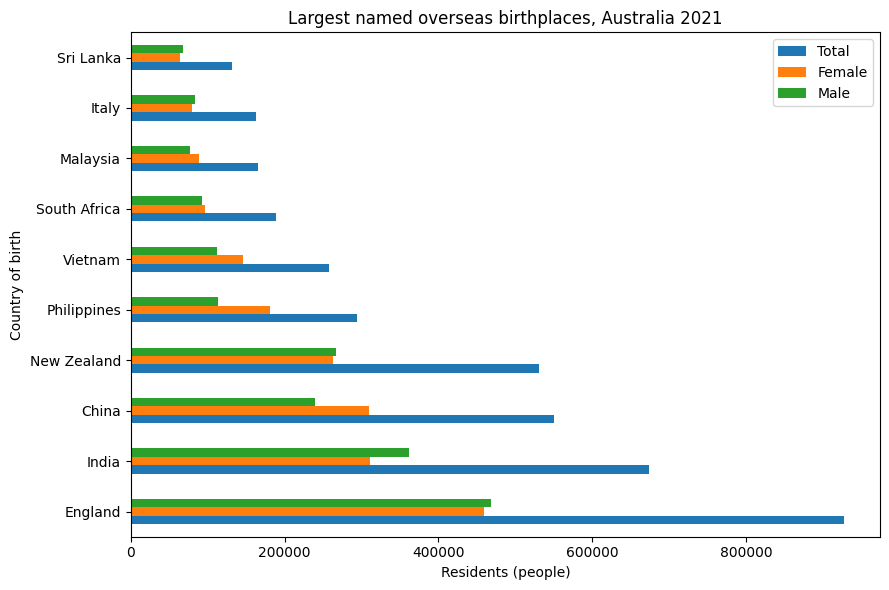

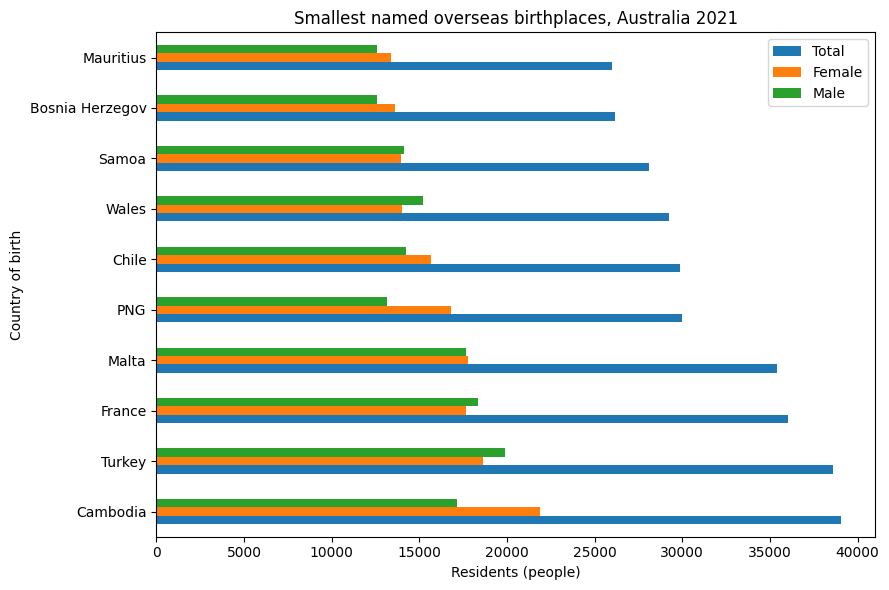

In [91]:
# Ten largest named overseas birthplaces in Australia
g09_df = load_table("G09")

exclude = {"P_Tot_Tot", "P_Australia_Tot", "P_Elsewhere_Tot", "P_COB_NS_Tot"}
rows = []

for column in g09_df.columns:
    if column.startswith("P_") and column.endswith("_Tot") and column not in exclude:
        country = column[2:-4]
        rows.append({
            "Country": country.replace("_", " "),
            "Female": g09_df[f"F_{country}_Tot"].item(),
            "Male": g09_df[f"M_{country}_Tot"].item(),
            "Total": g09_df[column].item(),
        })

birthplace_plot = pd.DataFrame(rows).set_index("Country")
birthplace_plot = birthplace_plot.sort_values("Total", ascending=False)

birthplace_plot.head(10)[["Total", "Female", "Male"]].plot.barh(figsize=(9, 6))
plt.title("Largest named overseas birthplaces, Australia 2021")
plt.xlabel("Residents (people)")
plt.ylabel("Country of birth")
plt.tight_layout()
plt.show()

birthplace_plot.tail(10)[["Total", "Female", "Male"]].plot.barh(figsize=(9, 6))
plt.title("Smallest named overseas birthplaces, Australia 2021")
plt.xlabel("Residents (people)")
plt.ylabel("Country of birth")
plt.tight_layout()
plt.show()

England, India, China and New Zealand are the four largest named overseas birthplaces in this table. "Elsewhere" is an aggregate category and is excluded from this ranking.

In [92]:
# Residents with a stated overseas birthplace

all_residents = g09_df["P_Tot_Tot"].item()
australia_born = g09_df["P_Australia_Tot"].item()
birthplace_not_stated = g09_df["P_COB_NS_Tot"].item()

overseas_born = all_residents - australia_born - birthplace_not_stated
female_overseas = (g09_df["F_Tot_Tot"].item() - g09_df["F_Australia_Tot"].item() - g09_df["F_COB_NS_Tot"].item())
male_overseas = (g09_df["M_Tot_Tot"].item() - g09_df["M_Australia_Tot"].item() - g09_df["M_COB_NS_Tot"].item())

print(f"Residents with a stated overseas birthplace: {overseas_born} ({overseas_born / all_residents * 100:.1f}% of all residents)")
print(f"Birthplace not stated: {birthplace_not_stated}")
print(f"Female share of stated overseas-born residents: {female_overseas / overseas_born * 100:.1f}%")
print(f"Male share of stated overseas-born residents: {male_overseas / overseas_born * 100:.1f}%")

Residents with a stated overseas birthplace: 7043708 (27.7% of all residents)
Birthplace not stated: 1358658
Female share of stated overseas-born residents: 51.7%
Male share of stated overseas-born residents: 48.3%


About **7.04 million** residents had a stated overseas birthplace in 2021, or **27.7%** of all residents. Birthplace was not stated for about **1.36 million**, so those people are not counted as overseas-born here.

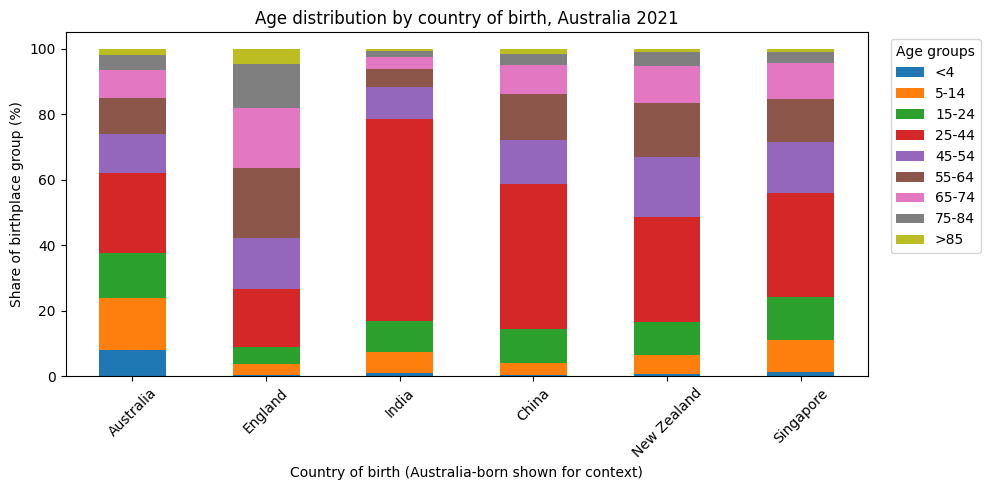

In [93]:
# Age distribution of selected groups

selected_countries = ["Australia", "England", "India", "China", "New_Zealand", "Singapore"]
age_groups = ["0_4", "5_14", "15_24", "25_44", "45_54", "55_64", "65_74", "75_84", "85ov"]
age_labels = ["<4", "5-14", "15-24", "25-44", "45-54", "55-64", "65-74", "75-84", ">85"]

age_plot = pd.DataFrame(index=age_labels)
for country in selected_countries:
    total = g09_df[f"P_{country}_Tot"].item()
    counts = [g09_df[f"P_{country}_{age}"].item() for age in age_groups]
    age_plot[country.replace("_", " ")] = [count / total * 100 for count in counts]

age_plot.T.plot.bar(stacked=True, figsize=(10, 5))
plt.title("Age distribution by country of birth, Australia 2021")
plt.ylabel("Share of birthplace group (%)")
plt.xlabel("Country of birth (Australia-born shown for context)")
plt.xticks(rotation=45)
plt.legend(title="Age groups", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Age profiles differ between birthplace groups: **61.7%** of India-born residents were aged 25-44, compared with **31.9%** of NZ-born residents. Australia-born residents provide a reference group. The chart uses the published age bands without estimating individual ages.

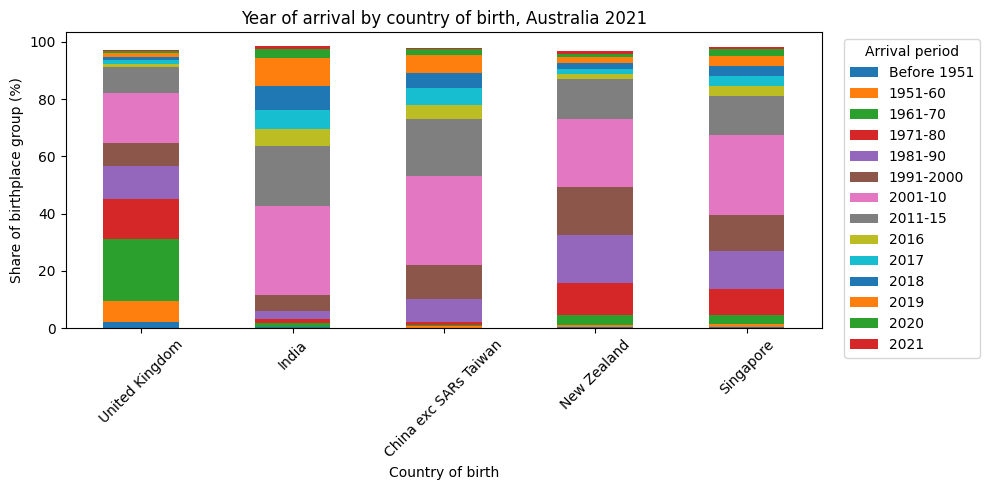

In [94]:
# Arrival years of overseas-born people living in Australia in 2021

g10_df = load_table("G10")

selected_countries = ["United_Kingdom", "India", "China_exc_SARs_Taiwan", "New_Zealand", "Singapore"]
year_labels = ["Before 1951", "1951-60", "1961-70", "1971-80", "1981-90", "1991-2000", "2001-10", "2011-15", "2016", "2017", "2018", "2019", "2020", "2021"]

year_plot = pd.DataFrame(index=year_labels)

for country in selected_countries:
    total = g10_df[f"{country}_Tot"].item()

    # The first 14 columns for each country are its arrival periods.
    prefix = "China_exc_SARs_" if country.startswith("China") else f"{country}_" # Different naming for china 
    columns = [name for name in g10_df.columns if name.startswith(prefix)]
    counts = g10_df[columns[:14]].iloc[0].tolist()

    label = country.replace("_", " ")
    year_plot[label] = [count / total * 100 for count in counts]

year_plot.T.plot.bar(stacked=True, figsize=(10, 5))
plt.title("Year of arrival by country of birth, Australia 2021")
plt.ylabel("Share of birthplace group (%)")
plt.xlabel("Country of birth")
plt.xticks(rotation=45)
plt.legend(title="Arrival period", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The bars describe **when people living in Australia in 2021 reported arriving**. About **34.8%** of India-born and **9.7%** of NZ-born residents reported arrival in 2016-2021. Bars stop below 100% where arrival year was not stated. G10 groups the UK together, while G09 lists England separately.

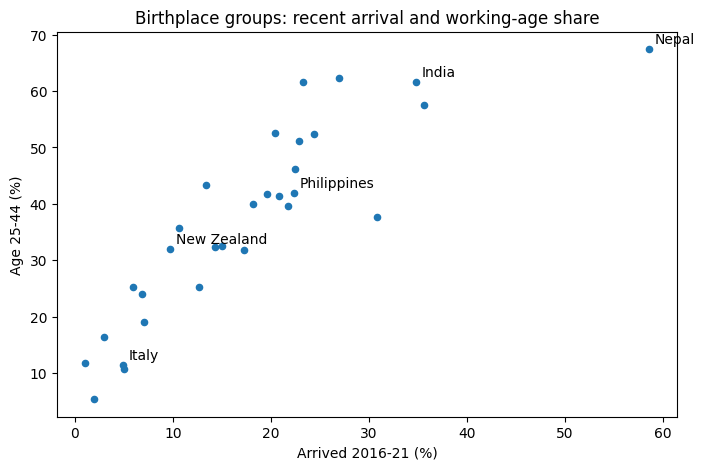

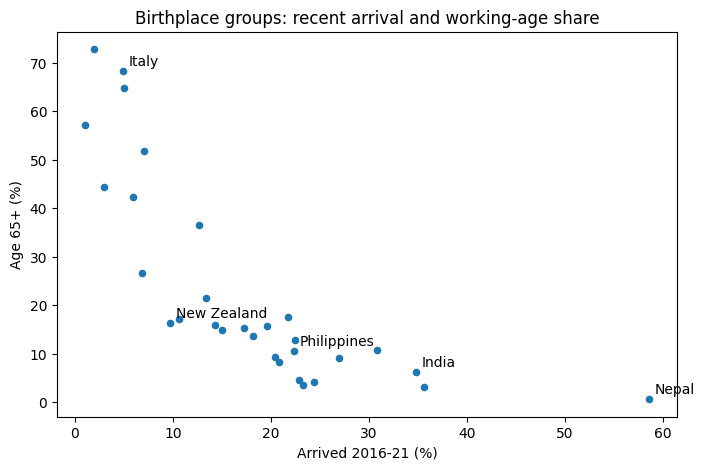

Compared 30 birthplace groups with matching G09 and G10 names.
Correlation between 'Arrived 2016-21' and 'Age 25-44': 0.86
Correlation between 'Arrived 2016-21' and 'Age 65+': -0.76


In [100]:
# Age vs arrival scatter plot

arrival_df = g10_df
birth_df = g09_df

# Use birthplaces with the same name in G09 and G10.
birth_countries = {name[2:-4] for name in birth_df.columns if name.startswith("P_") and name.endswith("_Tot")}
arrival_countries = {name[:-4] for name in arrival_df.columns if name.endswith("_Tot")}
common_countries = sorted((birth_countries & arrival_countries) - {"Tot"}) # Keep only countries listed in both dataframes

rows = []
for country in common_countries:
    birth_total = birth_df[f"P_{country}_Tot"].item()
    arrival_total = arrival_df[f"{country}_Tot"].item()
    
    recent = sum(arrival_df[f"{country}_{year}"].item() for year in range(2016, 2022))
    older = sum(birth_df[f"P_{country}_{age}"].item() for age in ["65_74", "75_84", "85ov"])

    rows.append({
        "Country": country.replace("_", " "),
        "Age 25-44 (%)": birth_df[f"P_{country}_25_44"].item() / birth_total * 100,
        "Age 65+ (%)": older / birth_total * 100,
        "Arrived 2016-21 (%)": recent / arrival_total * 100,
    })

features = pd.DataFrame(rows).set_index("Country")

features.plot.scatter(x="Arrived 2016-21 (%)", y="Age 25-44 (%)", figsize=(8, 5))
for country in ["India", "Nepal", "New Zealand", "Italy", "Philippines"]: # Annotate relevant countries 
    plt.annotate(country, (features.loc[country, "Arrived 2016-21 (%)"], features.loc[country, "Age 25-44 (%)"]), xytext=(4, 4), textcoords="offset points")
plt.title("Birthplace groups: recent arrival and working-age share")
plt.show()

features.plot.scatter(x="Arrived 2016-21 (%)", y="Age 65+ (%)", figsize=(8, 5))
for country in ["India", "Nepal", "New Zealand", "Italy", "Philippines"]: # Annotate relevant countries 
    plt.annotate(country, (features.loc[country, "Arrived 2016-21 (%)"], features.loc[country, "Age 65+ (%)"]), xytext=(4, 4), textcoords="offset points")
plt.title("Birthplace groups: recent arrival and working-age share")
plt.show()

print(f"Compared {len(features)} birthplace groups with matching G09 and G10 names.")
correlation = features["Arrived 2016-21 (%)"].corr(features["Age 25-44 (%)"])
print(f"Correlation between 'Arrived 2016-21' and 'Age 25-44': {correlation:.2f}")
correlation = features["Arrived 2016-21 (%)"].corr(features["Age 65+ (%)"])
print(f"Correlation between 'Arrived 2016-21' and 'Age 65+': {correlation:.2f}")

Across the **30 birthplace groups** whose G09 and G10 names match directly, recent-arrival share and age-25-44 share are strongly associated (correlation about **0.86**). This compares group summaries; the two tables do not identify whether the recently arrived people are themselves aged 25-44.

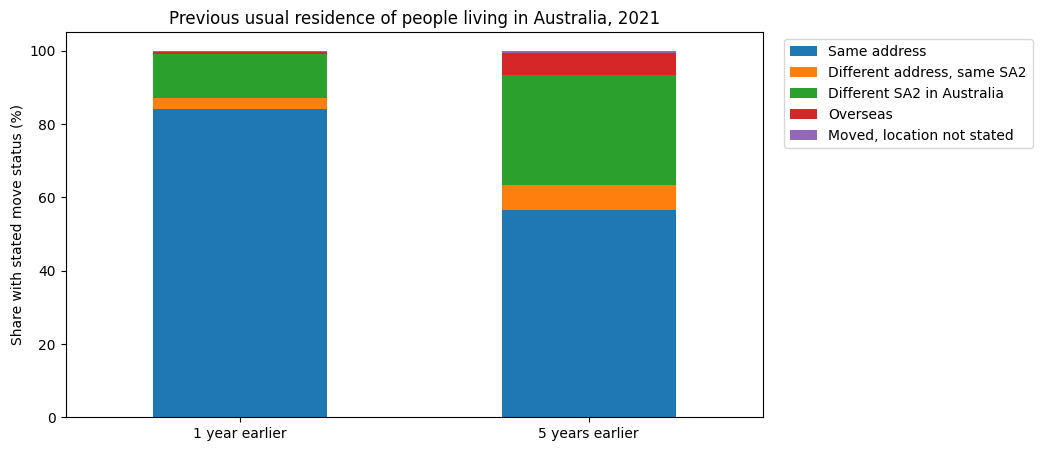

In [101]:
# Where 2021 Australian residents lived 1 and 5 years earlier (G44/G45)

residence_1 = load_table("G44").iloc[0]
residence_5 = load_table("G45").iloc[0]

mobility = pd.DataFrame(index=["1 year earlier", "5 years earlier"])
for label, row, years in [("1 year earlier", residence_1, "1"), ("5 years earlier", residence_5, "5")]:
    # Exclude people who did not state whether they had moved.
    total = row["Tot_P"] - row["N_stated_P"]
    values = {
        "Same address": row[f"Sme_Usl_ad_{years}_yr_ago_as_2021_P"],
        "Different address, same SA2": row[f"Dif_Usl_ad_{years}_yr_ago_Sme_SA2_P"],
        "Different SA2 in Australia": row[f"Dif_Us_ad_{years}_ago_Dif_SA2_Tot_P"],
        "Overseas": row[f"Difnt_Usl_add_{years}_yr_ago_OS_P"],
        "Moved, location not stated": row[f"Difnt_Usl_add_{years}_yr_ago_Ns_P"],
    }
    mobility.loc[label, list(values)] = [count / total * 100 for count in values.values()]

mobility.plot.bar(stacked=True, figsize=(9, 5))
plt.title("Previous usual residence of people living in Australia, 2021")
plt.ylabel("Share with stated move status (%)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

Most residents reported the same address one year earlier (**84.1%**). The overseas category was **0.7%** one year earlier and **5.7%** five years earlier. G44 and G45 cover different time spans and age-eligible populations, so these are not annual migration rates.

Average profile of each cluster (%):
         Age 25-44 (%)  Age 65+ (%)  Arrived 2016-21 (%)
Cluster                                                 
0                 40.8         13.1                 19.0
1                 16.6         51.6                  5.3
2                 62.1          4.6                 35.8
Cluster 0: Afghanistan, Canada, Fiji, Indonesia, Iran, Iraq, Ireland, Japan, Malaysia, New Zealand, Philippines, Singapore, South Africa, Sri Lanka, Thailand, Vietnam
Cluster 1: Croatia, Egypt, Germany, Greece, Italy, Lebanon, Netherlands, North Macedonia, Poland
Cluster 2: Bangladesh, India, Nepal, Pakistan, Taiwan


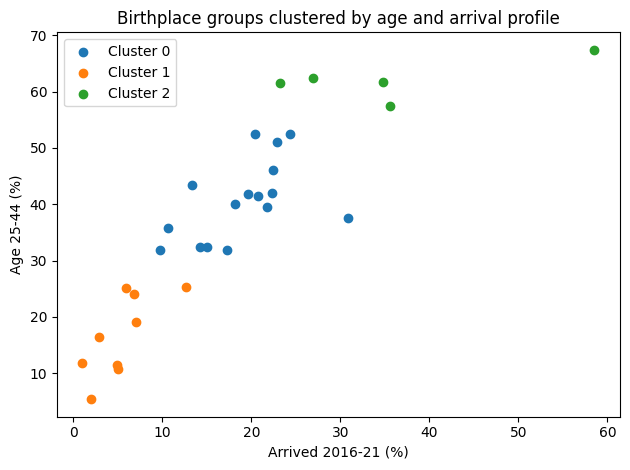

In [102]:
# Clustering: which birthplace groups have similar age and arrival profiles?

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

model_columns = ["Age 25-44 (%)", "Age 65+ (%)", "Arrived 2016-21 (%)"]
scaled_data = StandardScaler().fit_transform(features[model_columns])

# Three clusters are an exploratory choice for describing these groups.
model = KMeans(n_clusters=3, random_state=42, n_init=10)
features["Cluster"] = model.fit_predict(scaled_data)

print("Average profile of each cluster (%):")
print(features.groupby("Cluster")[model_columns].mean().round(1))
for cluster in sorted(features["Cluster"].unique()):
    members = features.index[features["Cluster"] == cluster].tolist()
    print(f"Cluster {cluster}: {', '.join(members)}")

for cluster, group in features.groupby("Cluster"):
    plt.scatter(group["Arrived 2016-21 (%)"], group["Age 25-44 (%)"], label=f"Cluster {cluster}")
plt.xlabel("Arrived 2016-21 (%)")
plt.ylabel("Age 25-44 (%)")
plt.title("Birthplace groups clustered by age and arrival profile")
plt.legend()
plt.tight_layout()
plt.show()

The three clusters describe broadly different age and arrival profiles. One contains younger, more recently arrived groups such as India and Nepal; another contains older, longer-settled groups such as Italy and Greece. Cluster averages treat each birthplace group equally, regardless of its population size. These patterns do not establish why anyone moved.